# Signal C: Idiosyncratic Volatility Anomaly

## Hypothesis

Signal C is a cross-sectional signal using idiosyncratic volatility (IVOL = std of residual returns over a recent window) to predict forward returns per coin. The mechanism leverages the fact that retail presence in crypto markets as a percentage of total market cap is far higher than in equity markets. I test both signs on IS and let the data pick.

**+IVOL (long high-IVOL, short low-IVOL):** high IVOL means the coin is under active speculation or info flow. If retail or institutional flow keeps pushing the same direction, high-IVOL coins continue earning and low-IVOL dormant coins do not. Matches the 2022 Annals of Op Research crypto finding (positive IVOL-return premium, though driven disproportionately by thin-dvol names).

**-IVOL (long low-IVOL, short high-IVOL):** three mechanisms converge here. First, info exhaustion, where high-IVOL coins dump once news is priced in. Second, lottery-seekers piling into dormant low-IVOL names and driving future returns. Third, plain mean reversion. Matches Ang, Hodrick, Xing & Zhang (2006) equity IVOL anomaly and Bali/Cakici/Whitelaw (2011) lottery preference.

**Prior:** weak lean toward -IVOL. The 2022 crypto paper's positive premium was concentrated in illiquid names, which the top-30 universe filter should mostly exclude. If that's right, equity-lit direction dominates. If not, the premium survives on liquid crypto too.


## Parameters

1. Universe: top-30 by trailing 30 day dollar volume built from monthly universe membership panel.
1. IS: 2020-03-01 -> 2023-12-31, OOS: 2024-01-01 -> end of panel
1. Signal: IVOL = rolling std of (coin return - market return)
   1. 4h resid over 30d
   1. daily resid over 30d
   1. rebalance: every 4h, per 3-days, or per-week
1. Performance Eval
   1. gross sharpe, net sharpe, maxDD, turnover, IC, IR
   1. t-stat of returns vs 0
   1. rank IC
1. Tune for Sensitivity:
   1. top 20 universe
   1. 60d beta residuals

## Set-Up

In [1]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

# NOTE: Either launch the jupyter notebook in the project directory or run chdir.

os.chdir('/Users/muditlam/Desktop/PythonJupyterCode/cryptoStatArbProject')

from quantlib import (
    rank_demean_normalize, compute_turnover, apply_costs,
    get_stats, factor_regression, drawdown, residual_returns_no_fill,
    BARS_PER_YEAR_4H, DEFAULT_COST_BPS_MARKET,
)

print("Working directory:", os.getcwd())

PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')
RESID_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'btc_resid_ret.pkl')
SIGNALA_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'signal_a_v1_regime.pkl')
SIGNALB_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'signal_b_v1_mom42_skip1_per3day.pkl')

print(PANEL_DATA_PATH)
os.makedirs(os.path.dirname(PANEL_DATA_PATH), exist_ok=True)
print(f"Save path: {PANEL_DATA_PATH}")

FREQ = '4h'
START_TS = '2019-01-01'

panels = pickle.load(open(PANEL_DATA_PATH, 'rb'))

px = panels['px']
ret = panels['ret']
dvol = panels['dvol']
taker_buy_dvol = panels['taker_buy_dvol']
num_trades = panels['num_trades']
high_px = panels['high_px']
low_px = panels['low_px']
close_px = panels['close_px']
universe = panels['universe']
universe_daily = panels['universe_daily']
universe_monthly = panels['universe_monthly']
candidate_symbols = panels['candidate_symbols']

print(f"Loaded pickle. px: {px.shape}, ret: {ret.shape})")

resid_panels = pickle.load(open(RESID_PANEL_DATA_PATH, 'rb'))

resid_ret_30 = resid_panels['resid_ret_30']
resid_ret_60 = resid_panels['resid_ret_60']

print(f"Loaded residual pickle. resid_ret_30: {resid_ret_30.shape})")

signala_panels = pickle.load(open(SIGNALA_PANEL_DATA_PATH, 'rb'))
signala_net_regime = signala_panels['net_regime']
signala_gross_regime = signala_panels['gross_regime']

print(f"Loaded signal a pickle. signala_net_regime: {signala_net_regime.shape}")

signalb_panels = pickle.load(open(SIGNALB_PANEL_DATA_PATH, 'rb'))
signalb_net_ret = signalb_panels['net_ret']
signalb_gross_ret = signalb_panels['gross_ret']

print(f"Loaded signal b pickle. signalb_net_ret: {signalb_net_ret.shape}")

Working directory: /Users/muditlam/Desktop/PythonJupyterCode/classProject
/Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Save path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Loaded pickle. px: (14417, 193), ret: (14417, 193))
Loaded residual pickle. resid_ret_30: (14417, 193))
Loaded signal a pickle. signala_net_regime: (14417,)
Loaded signal b pickle. signalb_net_ret: (14417,)


## Universe Construction

Universe shape: (14417, 193)
Entry rank: top 25, Exit rank: top 35

Monthly churn (first 24 months):
            universe_size  entries  exits  turnover_pct
2019-09-01              0        0      0           NaN
2019-10-01              0        0      0           NaN
2019-11-01              0        0      0           NaN
2019-12-01              0        0      0           NaN
2020-01-01              0        0      0           NaN
2020-02-01              0        0      0           NaN
2020-03-01             11       11      0          50.0
2020-04-01             12        1      0           4.2
2020-05-01             13        1      0           3.8
2020-06-01             16        3      0           9.4
2020-07-01             16        0      0           0.0
2020-08-01             17        1      0           2.9
2020-09-01             17        0      0           0.0
2020-10-01             17        0      0           0.0
2020-11-01             15        0      2           6.7
202

/var/folders/jd/_635316n0v32p9bp2q1n5bbm5n8rcm/T/ipykernel_1947/846544205.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries = u_monthly & ~u_monthly.shift(1).fillna(False).infer_objects(copy=False)
/var/folders/jd/_635316n0v32p9bp2q1n5bbm5n8rcm/T/ipykernel_1947/846544205.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits = ~u_monthly & u_monthly.shift(1).fillna(False).infer_objects(copy=False)


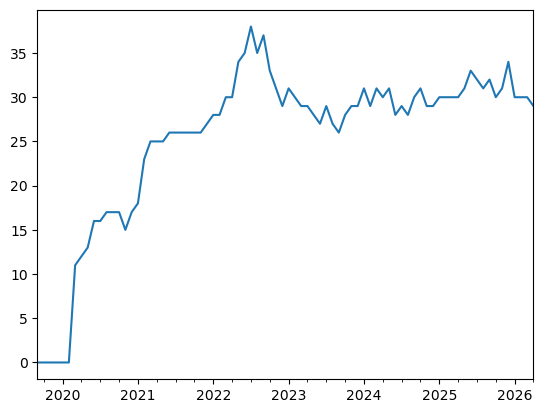

In [13]:
UNIVERSE_SIZE = 30  # top N coins by trailing 30d avg daily dollar volume.
MIN_HISTORY_DAYS = 180  # 180 days of data before eligible
MIN_DVOL_ABSOLUTE = 5_000  # coins below this are untradeable at 20bps assumption
ENTRY_RANK = 25 # coin volatility varies too much, this ensures volatility is not too high
EXIT_RANK = 35

dvol_daily = dvol.resample('1D').sum()

dvol_30d_avg = dvol_daily.rolling(30).mean()

daily_close = px.resample('1D').last()
history_days = daily_close.notna().cumsum()

history_aligned = history_days.reindex(dvol_30d_avg.index, method='ffill')

history_ok = history_aligned >= MIN_HISTORY_DAYS
dvol_ok = dvol_30d_avg >= MIN_DVOL_ABSOLUTE

vol_eligible = dvol_30d_avg.where(history_ok & dvol_ok)
vol_rank = vol_eligible.rank(axis=1, ascending=False, method='min')

rank_monthly = vol_rank.resample('MS').first()
dvol_ok_monthly = dvol_ok.resample('MS').first().fillna(False).infer_objects(copy=False)

universe_monthly_topN = pd.DataFrame(False, index=rank_monthly.index, columns=rank_monthly.columns)

prev_in = pd.Series(False, index=rank_monthly.columns)

for date in rank_monthly.index:
    ranks = rank_monthly.loc[date]
    dvol_ok_today = dvol_ok_monthly.loc[date]
    
    # A coin is in universe if:
    #   - it was in last month AND still ranks <= EXIT_RANK AND still passes vol floor
    #   - OR it's new this month and ranks <= ENTRY_RANK AND passes vol floor
    stays = prev_in & (ranks <= EXIT_RANK) & dvol_ok_today
    enters = (~prev_in) & (ranks <= ENTRY_RANK) & dvol_ok_today
    
    this_month = stays | enters
    universe_monthly_topN.loc[date] = this_month.fillna(False).infer_objects(copy=False)
    prev_in = this_month.fillna(False).infer_objects(copy=False)

universe_daily_topN = universe_monthly_topN.reindex(dvol_30d_avg.index, method='ffill').fillna(False).infer_objects(copy=False)
universe_topN = universe_daily_topN.reindex(px.index, method='ffill').fillna(False).infer_objects(copy=False)

print(f"Universe shape: {universe_topN.shape}")
print(f"Entry rank: top {ENTRY_RANK}, Exit rank: top {EXIT_RANK}\n")

universe_monthly_topN.sum(axis=1).plot()

u_monthly = universe_topN.resample('MS').first()
entries = u_monthly & ~u_monthly.shift(1).fillna(False).infer_objects(copy=False)
exits = ~u_monthly & u_monthly.shift(1).fillna(False).infer_objects(copy=False)

churn = pd.DataFrame({
    'universe_size': u_monthly.sum(axis=1),
    'entries': entries.sum(axis=1),
    'exits': exits.sum(axis=1),
})
churn['turnover_pct'] = (churn['entries'] + churn['exits']) / (2 * churn['universe_size'].replace(0, np.nan)) * 100

print("Monthly churn (first 24 months):")
print(churn.head(24).round(1))
print(f"\nMean monthly turnover: {churn['turnover_pct'].mean():.1f}%")
print(f"Median: {churn['turnover_pct'].median():.1f}%")
print(f"Max: {churn['turnover_pct'].max():.1f}%")
print(f"Max universe size: {churn['universe_size'].max()} Min universe size: {churn['universe_size'].min()}")
print(f"Current universe size: {universe.iloc[-1].sum():.0f}")

## Computing IVOL

1. Take residual returns from the ResidualReturns artifact and compute rolling volatility.
1. Resample to 1D as well so I can compare a 4h-bar IVOL series to a smoother daily IVOL series.

In [14]:
ivol_4h_30 = resid_ret_30.rolling(180).std()
ivol_4h_60 = resid_ret_60.rolling(180).std()

ivol_1d_30 = resid_ret_30.resample('1D').sum(min_count=1).rolling(30).std().shift(1).reindex(resid_ret_30.index, method='ffill')
ivol_1d_60 = resid_ret_60.resample('1D').sum(min_count=1).rolling(30).std().shift(1).reindex(resid_ret_60.index, method='ffill')

print(f"IVOL 4H Bars for 30 day window Residual Returns: \n{ivol_4h_30.median()}")
print(f"IVOL 1D Bars for 30 day window Residual Returns: \n{ivol_1d_30.median()}")

print(f"IVOL 4H Bars for 60 day window Residual Returns: \n{ivol_4h_60.median()}")
print(f"IVOL 1D Bars for 60 day window Residual Returns: \n{ivol_1d_60.median()}")

IVOL 4H Bars for 30 day window Residual Returns: 
1000MOGUSDT     0.108441
1000REKTUSDT    0.032906
1INCHUSDT       0.021111
A2ZUSDT         0.033478
AAVEUSDT        0.015866
                  ...   
YFIUSDT         0.019400
ZECUSDT         0.021051
ZENUSDT         0.022515
ZILUSDT         0.021433
ZRXUSDT         0.020251
Length: 193, dtype: float64
IVOL 1D Bars for 30 day window Residual Returns: 
1000MOGUSDT     0.172848
1000REKTUSDT    0.105364
1INCHUSDT       0.036185
A2ZUSDT         0.073858
AAVEUSDT        0.034368
                  ...   
YFIUSDT         0.035484
ZECUSDT         0.041083
ZENUSDT         0.050074
ZILUSDT         0.033984
ZRXUSDT         0.038762
Length: 193, dtype: float64
IVOL 4H Bars for 60 day window Residual Returns: 
1000MOGUSDT     0.114837
1000REKTUSDT    0.050028
1INCHUSDT       0.021429
A2ZUSDT         0.032621
AAVEUSDT        0.015949
                  ...   
YFIUSDT         0.019655
ZECUSDT         0.021094
ZENUSDT         0.022404
ZILUSDT         0.0

## Signal Construction + Performance Evaluation

In [22]:
IS_START = '2020-03-01'
IS_END = '2023-12-31'
OOS_START = '2024-01-01'
SPLIT_DATE = '2023-01-01'  # pre-2023 vs 2023 stability check

CADENCES = {
    'per_bar': 1,
    'per_day': 6,
    'per_3day': 18,
    'per_week': 42,
}

IVOL_VARIANTS = {
    '4h_30d': ivol_4h_30,
    '1d_30d': ivol_1d_30,
}

def create_signal_c(ivol_panel, sign_value, cadence_stride):
    signal = sign_value * ivol_panel
    weights = rank_demean_normalize(signal, universe_topN)
    weights_rebal = weights.iloc[::cadence_stride].reindex(ret.index, method='ffill')
    weights_shifted = weights_rebal.ffill().shift(1)
    bar_ret = (weights_shifted * ret).sum(axis=1)
    
    return {
        'signal': signal,
        'weights': weights,
        'weights_rebal': weights_rebal,
        'weights_shifted': weights_shifted,
        'bar_ret': bar_ret,
    }

SIGNS = {'+IVOL': 1, '-IVOL': -1}
results = []

for sign_name, sign_value in SIGNS.items():
    for variant_name, ivol_panel in IVOL_VARIANTS.items():
        for cadence_name, stride in CADENCES.items():
            result = create_signal_c(ivol_panel, sign_value, stride)
            bar_ret_full = result['bar_ret']
            bar_ret_is = bar_ret_full.loc[IS_START:IS_END]

            stats_is = get_stats(bar_ret_is, bars_per_year=BARS_PER_YEAR_4H)
            sharpe_is = stats_is['sharpe']

            # Stability split: pre-2023 vs 2023
            bar_ret_early = bar_ret_full.loc[IS_START:SPLIT_DATE]
            bar_ret_late = bar_ret_full.loc[SPLIT_DATE:IS_END]
            sharpe_early = get_stats(bar_ret_early, bars_per_year=BARS_PER_YEAR_4H)['sharpe']
            sharpe_late = get_stats(bar_ret_late, bars_per_year=BARS_PER_YEAR_4H)['sharpe']

            n = bar_ret_is.dropna().shape[0]
            t_stat = bar_ret_is.mean() / (bar_ret_is.std() / np.sqrt(n)) if bar_ret_is.std() > 0 else np.nan

            results.append({
                'sign': sign_name,
                'ivol_variant': variant_name,
                'cadence': cadence_name,
                'gross_sharpe': round(sharpe_is, 3),
                't_stat': round(t_stat, 2),
                'sharpe_pre23': round(sharpe_early, 3),
                'sharpe_23': round(sharpe_late, 3),
                'n_bars': n,
            })

phase1_results = pd.DataFrame(results).sort_values('gross_sharpe', ascending=False).reset_index(drop=True)
print(phase1_results.to_string(index=False))


 sign ivol_variant  cadence  gross_sharpe  t_stat  sharpe_pre23  sharpe_23  n_bars
+IVOL       4h_30d  per_bar         0.857    1.68         0.821      1.051    8406
+IVOL       4h_30d per_3day         0.757    1.48         0.680      1.101    8406
+IVOL       1d_30d  per_day         0.755    1.48         0.766      0.742    8406
+IVOL       4h_30d  per_day         0.744    1.46         0.693      0.973    8406
+IVOL       1d_30d per_3day         0.735    1.44         0.655      1.095    8406
+IVOL       4h_30d per_week         0.671    1.31         0.486      1.413    8406
+IVOL       1d_30d  per_bar         0.651    1.28         0.607      0.863    8406
+IVOL       1d_30d per_week         0.513    1.00         0.320      1.300    8406
-IVOL       1d_30d per_week        -0.513   -1.00        -0.320     -1.300    8406
-IVOL       1d_30d  per_bar        -0.651   -1.28        -0.607     -0.863    8406
-IVOL       4h_30d per_week        -0.671   -1.31        -0.486     -1.413    8406
-IVO

## Findings

1. Positive IVOL works better for IS returns.
1. A larger universe size would likely improve this signal since the lottery mechanism is more prominent in larger universes.
1. 4H signals at a per-bar cadence work best on gross Sharpe, but to control t-cost I'll commit to per_3day or per_week.

## Concerns

I'm concerned that regimes play a factor here. In Signal A I saw a regime change where post-2023 the market matured and became less volatile. So while +IVOL works on the IS sample, it's possible OOS deteriorates and -IVOL becomes more significant. The hypothesis is that as crypto markets matured they began following patterns found in equities markets, especially the lottery anomaly. +IVOL makes sense pre-2023 because the market had hype and lots of retail interest with a hold/buy-the-dip mentality.

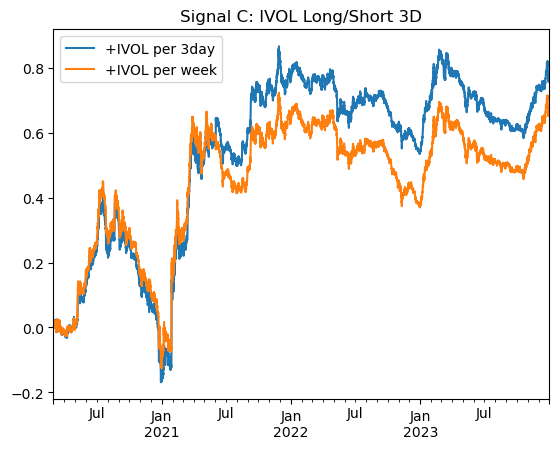

In [23]:
per_3day = CADENCES['per_3day']
per_week = CADENCES['per_week']

signal_c_ivol_plus_3day = create_signal_c(ivol_4h_30, 1, per_3day)
signal_c_ivol_minus_3day = create_signal_c(ivol_4h_30, -1, per_3day)

signal_c_ivol_plus_week = create_signal_c(ivol_4h_30, 1, per_week)
signal_c_ivol_minus_week = create_signal_c(ivol_4h_30, -1, per_week)

signal_c_ivol_plus_3day['bar_ret'].loc[IS_START:IS_END].cumsum().plot(label='+IVOL per 3day')
signal_c_ivol_plus_week['bar_ret'].loc[IS_START:IS_END].cumsum().plot(label='+IVOL per week')
plt.legend()
plt.title("Signal C: IVOL Long/Short 3D")
plt.show()


### Turnover and net returns

Cost the four candidate specs at 20bps using `apply_costs`. The plot compares cumulative net returns IS for the +IVOL 3-day vs +IVOL weekly variants.

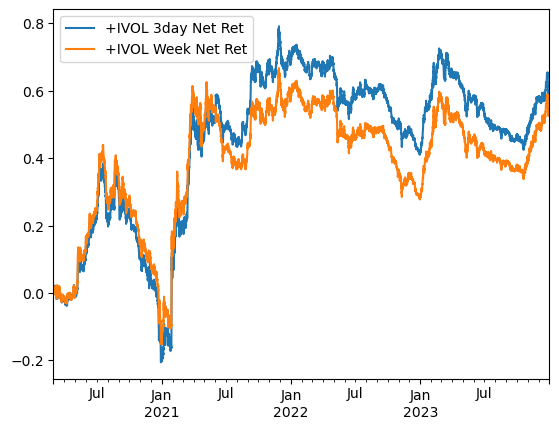

In [24]:
# Turnover

ivol_plus_3day_tcost = compute_turnover(signal_c_ivol_plus_3day['weights_rebal'])
net_ret_ivol_plus_3day = apply_costs(signal_c_ivol_plus_3day['bar_ret'], ivol_plus_3day_tcost)

ivol_minus_3day_tcost = compute_turnover(signal_c_ivol_minus_3day['weights_rebal'])
net_ret_ivol_minus_3day = apply_costs(signal_c_ivol_minus_3day['bar_ret'], ivol_minus_3day_tcost)

ivol_plus_week_tcost = compute_turnover(signal_c_ivol_plus_week['weights_rebal'])
net_ret_ivol_plus_week = apply_costs(signal_c_ivol_plus_week['bar_ret'], ivol_plus_week_tcost)

ivol_minus_week_tcost = compute_turnover(signal_c_ivol_minus_week['weights_rebal'])
net_ret_ivol_minus_week = apply_costs(signal_c_ivol_minus_week['bar_ret'], ivol_minus_week_tcost)

net_ret_ivol_plus_3day.loc[IS_START:IS_END].cumsum().plot(label='+IVOL 3day Net Ret')
net_ret_ivol_plus_week.loc[IS_START:IS_END].cumsum().plot(label='+IVOL Week Net Ret')
plt.legend()

### IS net stats

Sharpe, annualized return, max drawdown, and turnover for the two finalist cadences (+IVOL 3-day vs +IVOL weekly) on IS.

In [25]:
stats = []

for name, net_sig, weights_rebal in [('+IVOL 3day', net_ret_ivol_plus_3day, signal_c_ivol_plus_3day), ('+IVOL Week', net_ret_ivol_plus_week, signal_c_ivol_plus_week)]:
    ret_is_sig = net_sig.loc[IS_START:IS_END]
    ret_is_get_stats = get_stats(ret_is_sig)
    stats.append({
        'name': name,
        'sharpe': ret_is_get_stats['sharpe'],
        'ann_ret': ret_is_get_stats['ret_ann'],
        'max_drawdown': ret_is_get_stats['max_dd'],
        'turnover': compute_turnover(weights_rebal['weights_rebal']).mean(),
    })

net_results = pd.DataFrame(stats).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(net_results)

         name    sharpe   ann_ret  max_drawdown  turnover
0  +IVOL 3day  0.592058  0.156768     -0.456774  0.008844
1  +IVOL Week  0.543567  0.140338     -0.457634  0.006711


## Observations

- The 3day rebalancing shows higher turnover and lower returns
- The weekly rebalancing is more stable and has lower turnover
- The weekly rebalancing has marginally higher returns so it seems to be the preferred strategy given the signal doesn't need frequent rebalances

### IS / OOS / full sweep

Print the four candidate specs across the three reporting windows. Both signs and both cadences, so the IS/OOS sign-flip story (if any) is visible directly.

In [26]:
for window_name, (start, end) in [('IS', (IS_START, IS_END)),
                                    ('OOS', ('2024-01-01', None)),
                                    ('full', (None, None))]:
    ret_slice = net_ret_ivol_plus_3day.loc[start:end]
    s = get_stats(ret_slice)
    print(f"per_3day {window_name}: sharpe={s['sharpe']:.3f}, ret_ann={s['ret_ann']:.3f}, max_dd={s['max_dd']:.3f}")
    ret_slice = net_ret_ivol_minus_3day.loc[start:end]
    s = get_stats(ret_slice)
    print(f"per_3day -IVOL {window_name}: sharpe={s['sharpe']:.3f}, ret_ann={s['ret_ann']:.3f}, max_dd={s['max_dd']:.3f}")
    ret_slice = net_ret_ivol_plus_week.loc[start:end]
    s = get_stats(ret_slice)
    print(f"per_week {window_name}: sharpe={s['sharpe']:.3f}, ret_ann={s['ret_ann']:.3f}, max_dd={s['max_dd']:.3f}")
    ret_slice = net_ret_ivol_minus_week.loc[start:end]
    s = get_stats(ret_slice)
    print(f"per_week -IVOL {window_name}: sharpe={s['sharpe']:.3f}, ret_ann={s['ret_ann']:.3f}, max_dd={s['max_dd']:.3f}")


per_3day IS: sharpe=0.592, ret_ann=0.157, max_dd=-0.457
per_3day -IVOL IS: sharpe=-0.922, ret_ann=-0.244, max_dd=-0.705
per_week IS: sharpe=0.544, ret_ann=0.140, max_dd=-0.458
per_week -IVOL IS: sharpe=-0.798, ret_ann=-0.206, max_dd=-0.645
per_3day OOS: sharpe=-0.267, ret_ann=-0.060, max_dd=-0.335
per_3day -IVOL OOS: sharpe=-0.073, ret_ann=-0.016, max_dd=-0.304
per_week OOS: sharpe=-0.595, ret_ann=-0.134, max_dd=-0.387
per_week -IVOL OOS: sharpe=0.336, ret_ann=0.076, max_dd=-0.187
per_3day full: sharpe=0.292, ret_ann=0.070, max_dd=-0.457
per_3day -IVOL full: sharpe=-0.612, ret_ann=-0.148, max_dd=-0.768
per_week full: sharpe=0.146, ret_ann=0.035, max_dd=-0.458
per_week -IVOL full: sharpe=-0.393, ret_ann=-0.094, max_dd=-0.677


### Full-sample equity comparison

All four candidate specs plotted across the entire sample. The IS / OOS regime break should be visible if it exists.

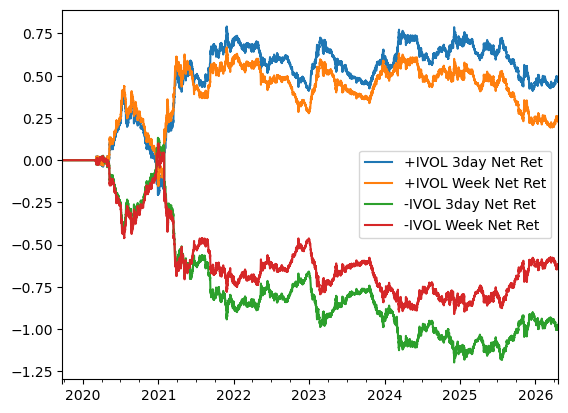

In [27]:
net_ret_ivol_plus_3day.cumsum().plot(label='+IVOL 3day Net Ret')
net_ret_ivol_plus_week.cumsum().plot(label='+IVOL Week Net Ret')
net_ret_ivol_minus_3day.cumsum().plot(label='-IVOL 3day Net Ret')
net_ret_ivol_minus_week.cumsum().plot(label='-IVOL Week Net Ret')
plt.legend()

### Correlation with Signals A and B

Bar-level correlation of the committed +IVOL 3-day spec against Signal A (regime-gated reversal) and Signal B (cross-sectional momentum), split by IS / OOS / full. 

In [28]:
for window_name, (start, end) in [('IS', (IS_START, IS_END)),
                                    ('OOS', (OOS_START, None)),
                                    ('full', (None, None))]:
    c = net_ret_ivol_plus_3day.loc[start:end]
    a = signala_net_regime.loc[start:end]
    b = signalb_net_ret.loc[start:end]
    print(f"{window_name}: corr(C, A) = {c.corr(a):+.3f}, corr(C, B) = {c.corr(b):+.3f}")


IS: corr(C, A) = -0.043, corr(C, B) = +0.200
OOS: corr(C, A) = -0.062, corr(C, B) = +0.079
full: corr(C, A) = -0.049, corr(C, B) = +0.161


## Conclusions

**Committed spec:** +IVOL × 4h_30d × per_3day on top-30 universe.

**Standalone performance at 20bps:**
- IS net Sharpe: +0.59
- OOS net Sharpe: -0.25
- Full net Sharpe: +0.31
- Max DD: -45.7%

Not a standalone-tradeable signal. The IS/OOS gap reflects an apparent sign flip in the IVOL-return relationship: +IVOL wins IS (consistent with the 2022 Annals of Op Research crypto finding), while -IVOL gross wins OOS (consistent with Ang et al. 2006 equity anomaly). Plausible story is that crypto matured post-2022 from retail-speculation-driven to more equity-like, which is also what I saw in Signal A.

**Correlation with other signals (net, bar-level):**
- corr(C, A): -0.043 IS, -0.062 OOS. Essentially zero and stable.
- corr(C, B): +0.079 IS, +0.161 OOS. Mildly positive, weakening OOS.

Signal C contributes diversification against A, and acceptable diversification against B. Its value in the combined portfolio is not from standalone Sharpe but from the near-zero correlation with A.

**Deferred as future work:**
- Top-50 universe lottery-mechanism hypothesis (untestable cleanly post-peek).
- 60d $\beta$ residual sensitivity on committed spec.


## Save

In [29]:
panels = {
    'weights': signal_c_ivol_plus_3day['weights_rebal'],
    'gross_ret': signal_c_ivol_plus_3day['bar_ret'],
    'net_ret': net_ret_ivol_plus_3day,
    'turnover': ivol_plus_3day_tcost,
    'config': {
        'sign': '+IVOL',
        'ivol_variant': '4h_30d',
        'cadence_name': 'per_3day',
        'cadence_bars': 18,
        'universe': 'top-30 (entry=25, exit=35)',
        'ivol_window_bars': 180,
        'cost_bps': 20,
        'residual_source': 'btc_resid_ret.pkl',
    },
}

save_path = os.path.join(PROJECT_DIR, 'data', 'signal_c_v1_ivol_plus_4h30d_per3day.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(panels, f)
print(f"Saved. Path: {save_path}")
print(f"net_ret shape: {net_ret_ivol_plus_3day.shape}")


Saved. Path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/signal_c_v1_ivol_plus_4h30d_per3day.pkl
net_ret shape: (14417,)
